<a href="https://colab.research.google.com/github/RicoRonald/RicoRonaldM_G.231.23.0128TransformasiCitra/blob/main/Prak3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2, numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


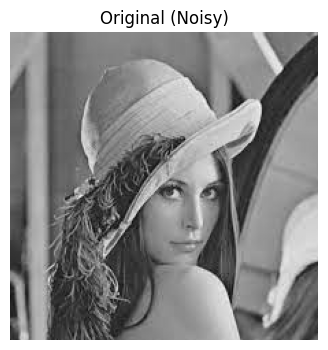

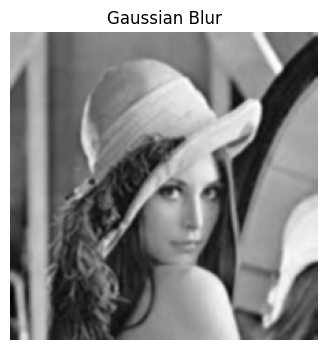

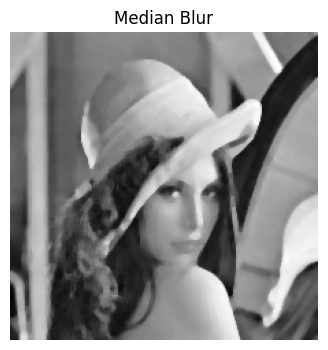

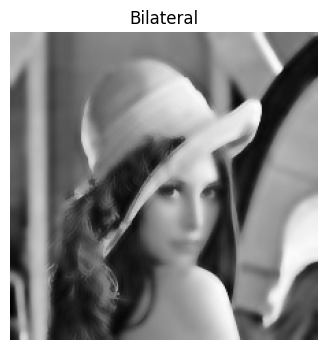

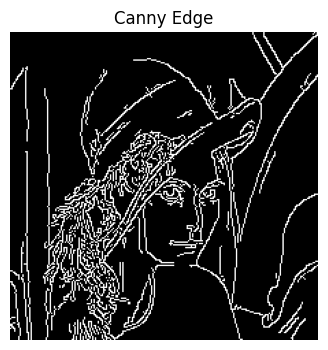

In [ ]:
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/lena.jpg", 0)
assert img is not None, "lena.jpg tidak ditemukan."

gauss = cv2.GaussianBlur(img, (5,5), 0)
median = cv2.medianBlur(img, 5)
bilateral = cv2.bilateralFilter(img, 9, 75, 75)
garis = cv2.Canny(img, 100, 200)

titles = ["Original (Noisy)", "Gaussian Blur", "Median Blur", "Bilateral", "Canny Edge"]
images = [img, gauss, median, bilateral, garis]

for t,im in zip(titles, images):
  plt.figure(figsize=(5,4)); plt.imshow(im, cmap='gray'); plt.title(t); plt.axis("off"); plt.show()

In [ ]:
from skimage.restoration import denoise_wavelet

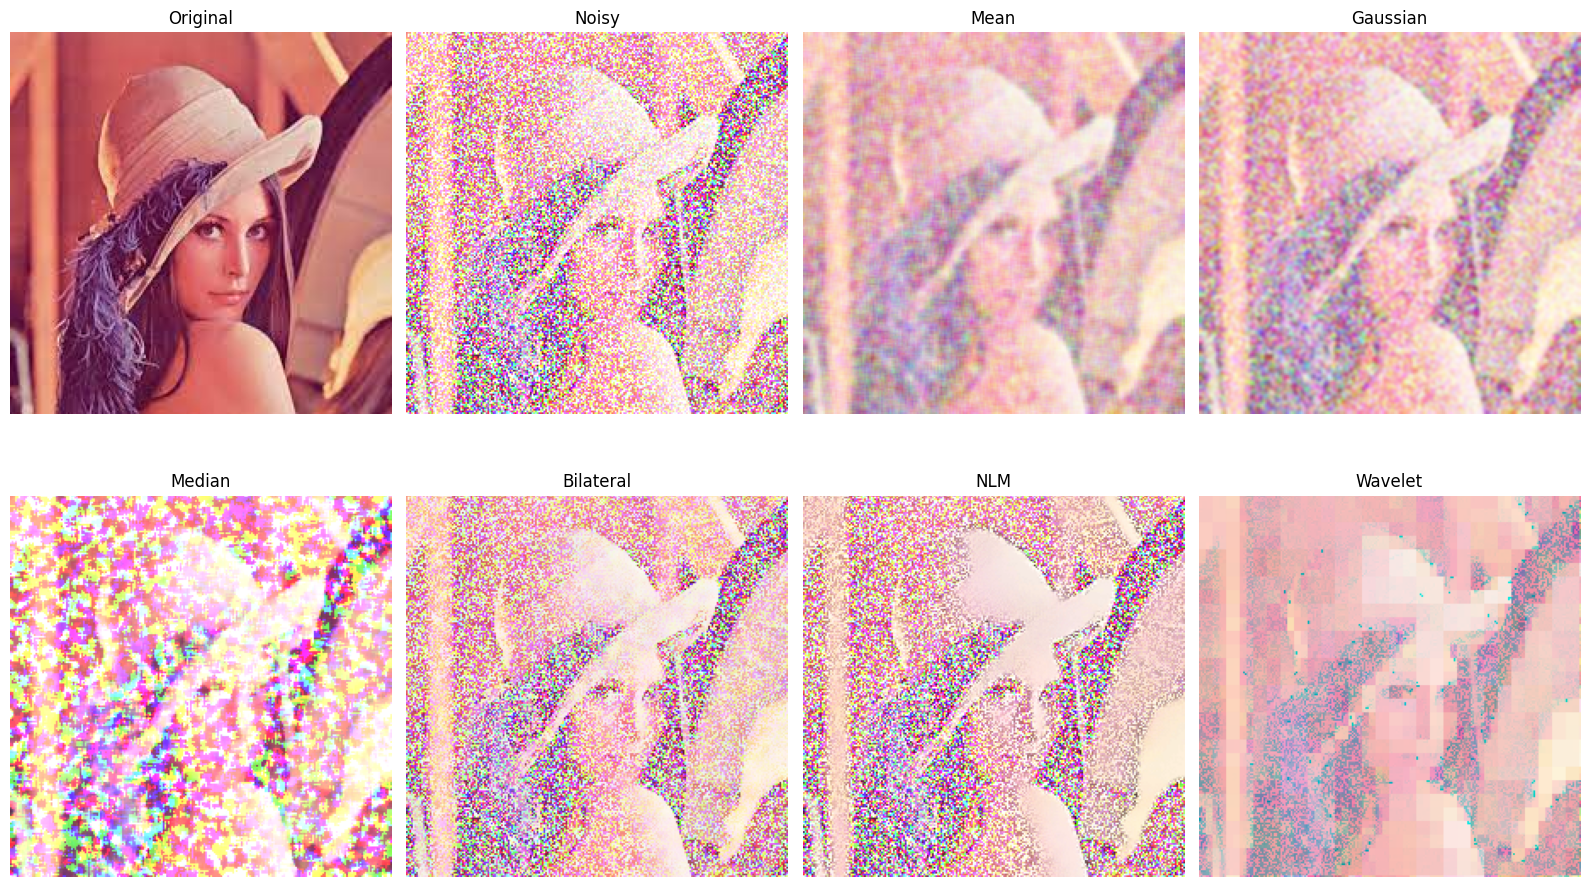

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import denoise_wavelet

# --- Load image --
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/lena.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- Add synthetic Gaussian noise for testing --
noise = np.random.normal(0, 25, img.shape).astype(np.uint8)
noisy_img = cv2.add(img, noise)

# --- Apply different denoising methods --
mean = cv2.blur(noisy_img, (5, 5))
gaussian = cv2.GaussianBlur(noisy_img, (5, 5), 0)
median = cv2.medianBlur(noisy_img, 5)
bilateral = cv2.bilateralFilter(noisy_img, 9, 75, 75)
nlm = cv2.fastNlMeansDenoisingColored(noisy_img, None, 10, 10, 7, 21)
wavelet = (denoise_wavelet(noisy_img / 255.0, channel_axis=-1, rescale_sigma=True) * 255).astype(np.uint8)

# --- Display results in a single row --
titles = ['Original', 'Noisy', 'Mean', 'Gaussian', 'Median', 'Bilateral', 'NLM', 'Wavelet']
images = [img, noisy_img, mean, gaussian, median, bilateral, nlm, wavelet]

plt.figure(figsize=(16, 10))
for i in range(len(images)):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

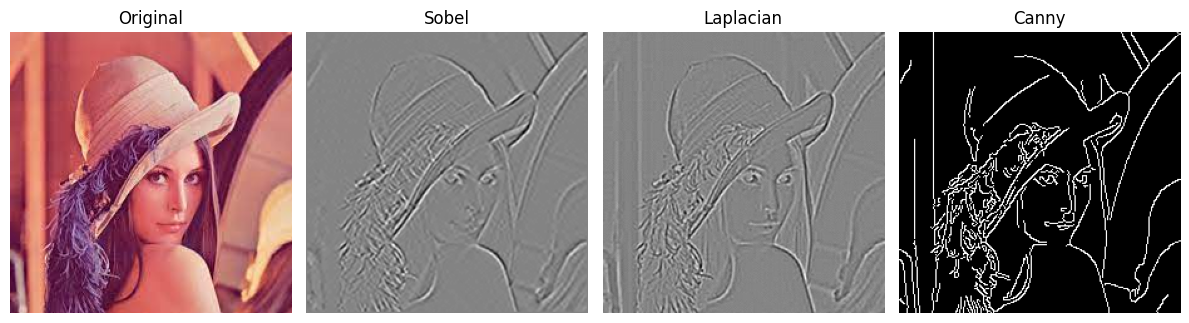

In [ ]:
#Load grayscale image
img2 = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/lena.jpg", 0)

# Apply edge detection methods
gauss2 = cv2.GaussianBlur(img2, (3,3), 0)

sobel = cv2.Sobel(gauss2, cv2.CV_64F, 1, 1, ksize=3)
laplacian = cv2.Laplacian(gauss2, cv2.CV_64F)
canny = cv2.Canny(gauss2, 100, 200)

# Display
titles = ['Original', 'Sobel', 'Laplacian', 'Canny']
images = [img, sobel, laplacian, canny]

plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from scipy import ndimage

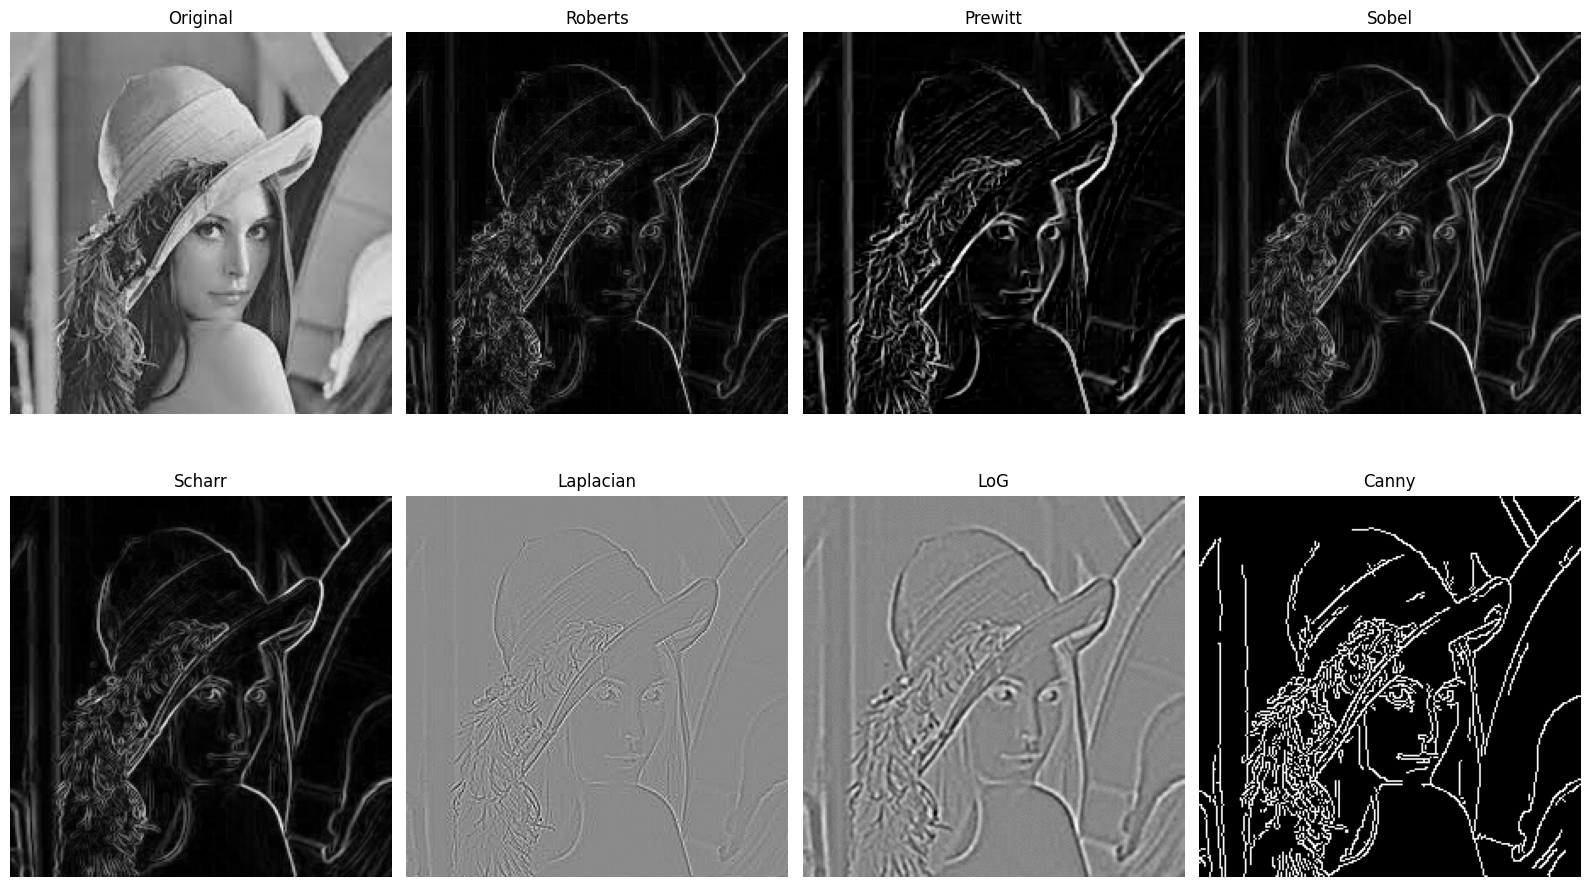

In [ ]:
# --- Load image in grayscale --
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/lena.jpg", cv2.IMREAD_GRAYSCALE)


roberts_cross_v = np.array([[1, 0],
                          [0, -1]])
roberts_cross_h = np.array([[0, 1],
                          [-1, 0]])
roberts_v = ndimage.convolve(img.astype(float), roberts_cross_v)
roberts_h = ndimage.convolve(img.astype(float), roberts_cross_h)
roberts = np.sqrt(roberts_v**2 + roberts_h**2)

prewitt_kx = np.array([[1, 0, -1],
                      [1, 0, -1],
                      [1, 0, -1]])
prewitt_ky = np.array([[1, 1, 1],
                      [0, 0, 0],
                      [-1, -1, -1]])
prewitt_x = cv2.filter2D(img, -1, prewitt_kx)
prewitt_y = cv2.filter2D(img, -1, prewitt_ky)
prewitt = cv2.magnitude(prewitt_x.astype(float), prewitt_y.astype(float))

sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)

scharrx = cv2.Scharr(img, cv2.CV_64F, 1, 0)
scharry = cv2.Scharr(img, cv2.CV_64F, 0, 1)
scharr = cv2.magnitude(scharrx, scharry)

laplacian = cv2.Laplacian(img, cv2.CV_64F)

gaussian = cv2.GaussianBlur(img, (5, 5), 0)
log = cv2.Laplacian(gaussian, cv2.CV_64F)

canny = cv2.Canny(img, 100, 200)

# --- Normalize results for display --
def normalize(img):
  return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

results = {
  "Original": img,
  "Roberts": normalize(roberts),
  "Prewitt": normalize(prewitt),
  "Sobel": normalize(sobel),
  "Scharr": normalize(scharr),
  "Laplacian": normalize(laplacian),
  "LoG": normalize(log),
  "Canny": canny
}

# --- Display all methods side-by-side --
plt.figure(figsize=(16, 10))
for i, (name, image) in enumerate(results.items()):
  plt.subplot(2, 4, i+1)
  plt.imshow(image, cmap='gray')
  plt.title(name)
  plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from scipy import ndimage

In [ ]:
roberts_cross_v = np.array([[1, 0],
                          [0, -1]])
roberts_cross_h = np.array([[0, 1],
                          [-1, 0]])
roberts_v = ndimage.convolve(img.astype(float), roberts_cross_v)
roberts_h = ndimage.convolve(img.astype(float), roberts_cross_h)
roberts = np.sqrt(roberts_v**2 + roberts_h**2)

In [ ]:
def normalize(img):
  return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

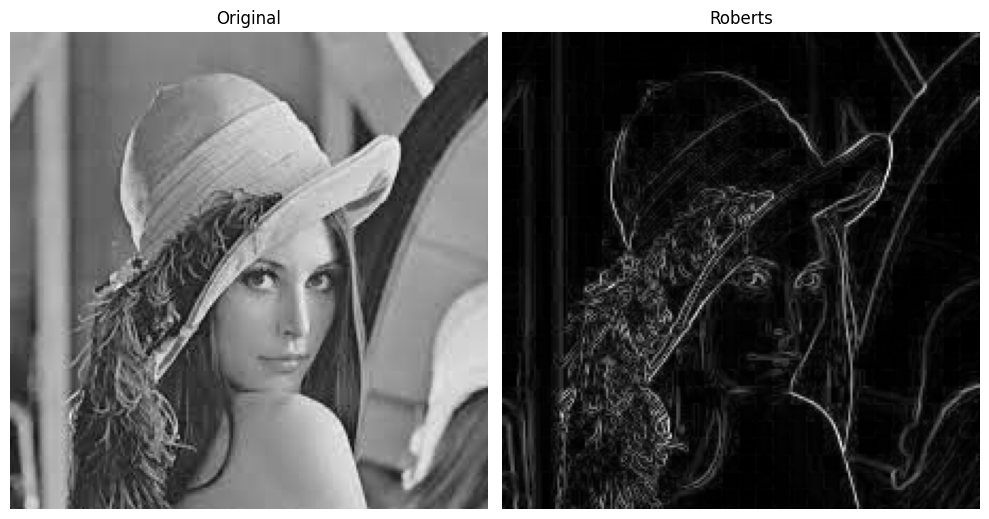

In [ ]:
results = {
  "Original": img,
  "Roberts": normalize(roberts)
  }
# --- Display all methods side-by-side --
plt.figure(figsize=(10, 8))
for i, (name, image) in enumerate(results.items()):
  plt.subplot(1, 2, i+1)
  plt.imshow(image, cmap='gray')
  plt.title(name)
  plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


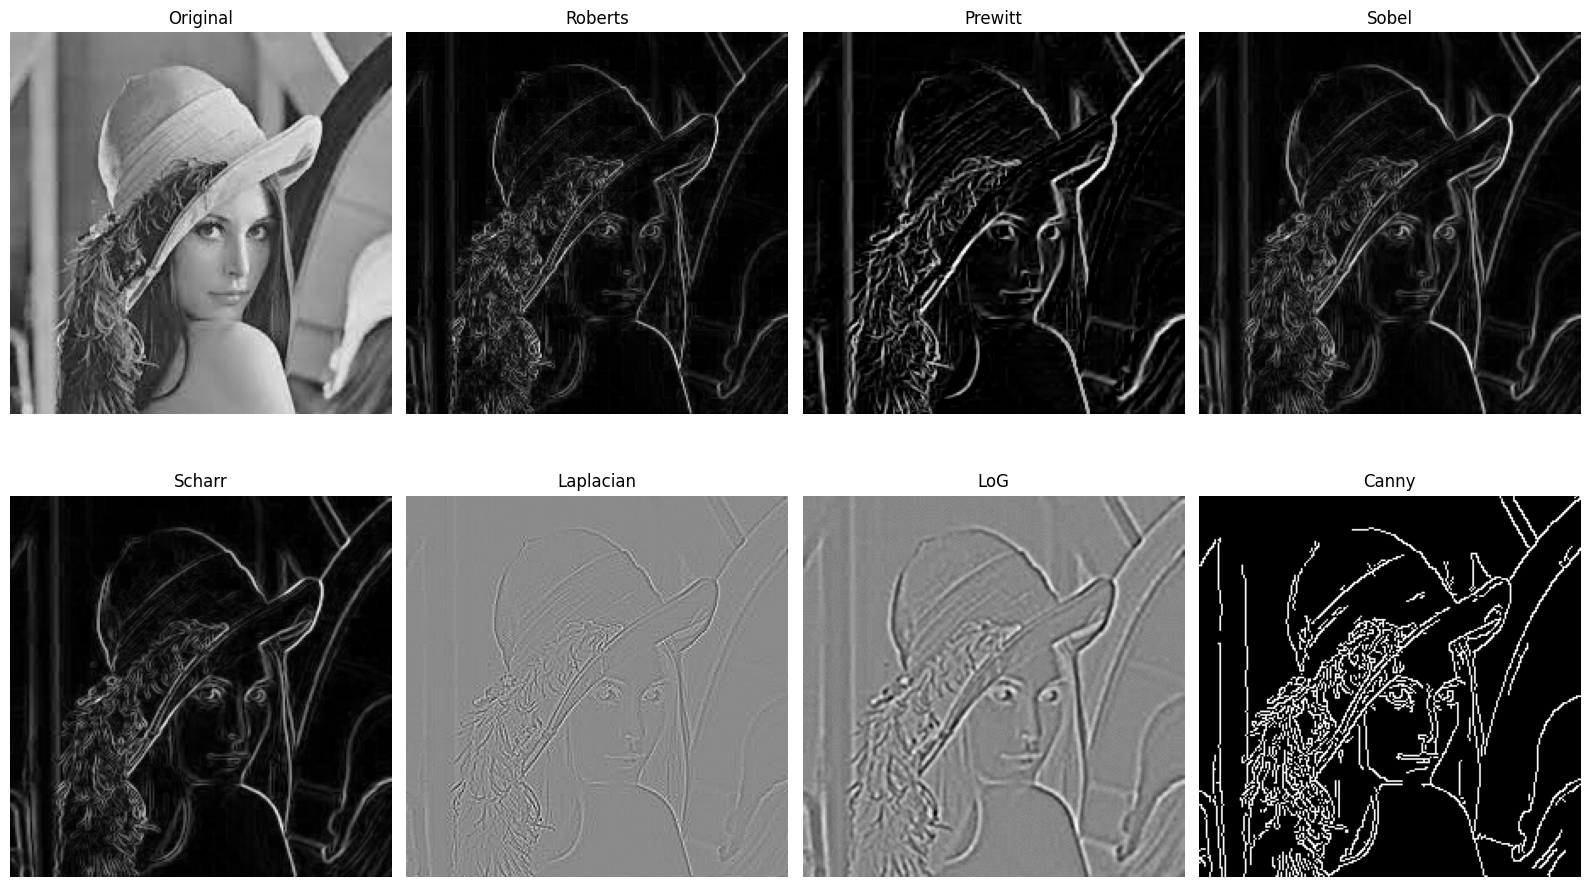

📊 Edge Detection Evaluation Metrics:

Method           PSNR       SSIM
Roberts          6.51     0.0528
Prewitt          6.40     0.0249
Sobel            6.67     0.0446
Scharr           6.65     0.0458
Laplacian       13.29     0.0664
LoG             12.38    -0.1328
Canny            5.41     0.0031


In [ ]:
#--- Load images --
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/lena.jpg", cv2.IMREAD_GRAYSCALE)
# Pastikan path ground truth benar atau gunakan gambar yang ada sebagai dummy jika hanya ingin testing
gt_path = "/content/drive/MyDrive/Colab Notebooks/Computer Vision/lena.jpg"
gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

# Check if ground truth image is loaded
if gt is None:
    print(f"Peringatan: Ground truth tidak ditemukan di {gt_path}. Metrik PSNR/SSIM tidak dapat dihitung.")
else:
    if img.shape != gt.shape:
        gt = cv2.resize(gt, (img.shape[1], img.shape[0]))

# --- Edge Detection Methods ---
roberts_cross_v = np.array([[1, 0], [0, -1]])
roberts_cross_h = np.array([[0, 1], [-1, 0]])
roberts_v = ndimage.convolve(img.astype(float), roberts_cross_v)
roberts_h = ndimage.convolve(img.astype(float), roberts_cross_h)
roberts = np.sqrt(roberts_v**2 + roberts_h**2)

prewitt_kx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
prewitt_ky = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
prewitt_x = cv2.filter2D(img, -1, prewitt_kx)
prewitt_y = cv2.filter2D(img, -1, prewitt_ky)
prewitt = cv2.magnitude(prewitt_x.astype(float), prewitt_y.astype(float))

sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)

scharrx = cv2.Scharr(img, cv2.CV_64F, 1, 0)
scharry = cv2.Scharr(img, cv2.CV_64F, 0, 1)
scharr = cv2.magnitude(scharrx, scharry)

laplacian = cv2.Laplacian(img, cv2.CV_64F)

gaussian = cv2.GaussianBlur(img, (5, 5), 0)
log = cv2.Laplacian(gaussian, cv2.CV_64F)

canny = cv2.Canny(img, 100, 200)

# --- Normalize all to 8-bit (0–255) ---
def normalize(img_in):
    return cv2.normalize(img_in, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

methods = {
    "Roberts": normalize(roberts),
    "Prewitt": normalize(prewitt),
    "Sobel": normalize(sobel),
    "Scharr": normalize(scharr),
    "Laplacian": normalize(laplacian),
    "LoG": normalize(log),
    "Canny": canny
}

# --- Compute Metrics (Hanya jika gt ada) ---
metrics = []
if gt is not None:
    for name, edge_map in methods.items():
        edge_map_resized = cv2.resize(edge_map, (gt.shape[1], gt.shape[0]))
        psnr_value = psnr(gt, edge_map_resized)
        ssim_value = ssim(gt, edge_map_resized)
        metrics.append((name, psnr_value, ssim_value))

# --- Display Results ---
plt.figure(figsize=(16, 10))
plt.subplot(2, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, (name, edge_map) in enumerate(methods.items(), start=2):
    plt.subplot(2, 4, i)
    plt.imshow(edge_map, cmap='gray')
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()

# --- Print PSNR & SSIM ---
if metrics:
    print("📊 Edge Detection Evaluation Metrics:\n")
    print("{:<10} {:>10} {:>10}".format("Method", "PSNR", "SSIM"))
    for name, p, s in metrics:
        print("{:<10} {:>10.2f} {:>10.4f}".format(name, p, s))